# PCA on Correlation Matrices (Train Fit, Test Evaluation)
Fit PCA on flattened train correlation matrices and reconstruct the test matrices using the learned components.
Compute reconstruction errors (MSE, MAE, Frobenius) on the test set, while explained variance is reported from the train fit.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [2]:
# Dataset path configuration
DATA_DIR = Path('../data/processed/dataset')
DATASET_NAME = 'data_00_20_w724_s10'
DATASET_DIR = DATA_DIR / DATASET_NAME

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Dataset folder: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt


In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_corr_payload(TRAIN_FILE)
val_corr, val_meta = load_corr_payload(VAL_FILE)
test_corr, test_meta = load_corr_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (289, 362, 362)
val_corr shape:   (82, 362, 362)
test_corr shape:  (41, 362, 362)


## Step 2: Prepare Train/Val/Test Matrices
Use each correlation matrix directly as a 2D input (N x N).
The validation split is loaded for completeness but not used later.

In [4]:
train_np = train_corr.numpy()
val_np = val_corr.numpy()
test_np = test_corr.numpy()

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Val matrices:   {n_val}')
print(f'Test matrices:  {n_test}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')

Train matrices: 289
Val matrices:   82
Test matrices:  41
Assets per matrix (N): 362
Each input matrix shape: (362, 362)


## Step 3: Fit PCA on Train, Reconstruct Test
For every matrix:
- Flatten each N x N matrix into a vector of length N*N
- Fit PCA on the train split only
- Apply PCA to the test split and inverse transform to reconstruct
Errors are computed on the test split; explained variance is from the train fit.

In [5]:
def rank_k_reconstruct(corr_mats: np.ndarray, n_components: int):
    if corr_mats.ndim != 3 or corr_mats.shape[1] != corr_mats.shape[2]:
        raise ValueError(f'Expected shape (n_samples, N, N), got {corr_mats.shape}')

    n_samples, n_assets, _ = corr_mats.shape
    if not (1 <= n_components <= n_assets):
        raise ValueError(f'n_components must be in [1, {n_assets}]')

    recon_mats = np.empty_like(corr_mats, dtype=float)
    explained_variance = np.zeros((n_samples, n_components), dtype=float)

    for i in range(n_samples):
        mat = corr_mats[i]

        # Eigen-decomposition of the correlation matrix (symmetric).
        eigenvalues, eigenvectors = np.linalg.eigh(mat)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        top_vals = eigenvalues[:n_components]
        top_vecs = eigenvectors[:, :n_components]

        # Rank-K reconstruction using the top eigenpairs.
        recon_mats[i] = (top_vecs * top_vals) @ top_vecs.T

        total_var = float(np.sum(eigenvalues))
        explained_variance[i, :] = 0.0 if total_var == 0.0 else (top_vals / total_var)

    return {
        'recon_corr': recon_mats,
        'explained_variance': explained_variance
    }

In [6]:
def rank_k_reconstruct_flattened(train_mats: np.ndarray, eval_mats: np.ndarray, n_components: int):
    """
    Applica la PCA sulle matrici di correlazione flattenate.
    La PCA viene fittata sul train set e poi applicata a un set di valutazione.

    Parameters:
    -----------
    train_mats : np.ndarray
        Array di shape (n_train, N, N) contenente le matrici di correlazione del train.
    eval_mats : np.ndarray
        Array di shape (n_eval, N, N) su cui applicare la PCA fittata.
    n_components : int
        Numero di componenti principali da mantenere per la PCA.

    Returns:
    --------
    dict
        'recon_corr': Matrici ricostruite di shape (n_eval, N, N)
        'explained_variance': Ratio della varianza spiegata (dal train)
        'pca': Oggetto PCA fittato
    """
    if train_mats.ndim != 3 or train_mats.shape[1] != train_mats.shape[2]:
        raise ValueError(f'Expected train shape (n_samples, N, N), got {train_mats.shape}')
    if eval_mats.ndim != 3 or eval_mats.shape[1] != eval_mats.shape[2]:
        raise ValueError(f'Expected eval shape (n_samples, N, N), got {eval_mats.shape}')
    
    n_train, n_assets, _ = train_mats.shape
    n_eval, n_assets_eval, _ = eval_mats.shape
    if n_assets_eval != n_assets:
        raise ValueError(f'Train/eval asset dims mismatch: {train_mats.shape} vs {eval_mats.shape}')
    
    n_features = n_assets * n_assets
    if not (1 <= n_components <= min(n_train, n_features)):
        raise ValueError(f'n_components must be in [1, {min(n_train, n_features)}]')
    
    # 1. Flattening: (n_samples, N, N) -> (n_samples, N*N)
    train_flat = train_mats.reshape(n_train, n_features)
    eval_flat = eval_mats.reshape(n_eval, n_features)
    
    # 2. Fit PCA on train, then reconstruct eval
    pca = PCA(n_components=n_components)
    pca.fit(train_flat)
    eval_recon = pca.inverse_transform(pca.transform(eval_flat))
    
    # 3. Reshape inverso: (n_eval, N*N) -> (n_eval, N, N)
    recon_mats = eval_recon.reshape(n_eval, n_assets, n_assets)
    
    return {
        'recon_corr': recon_mats,
        'explained_variance': pca.explained_variance_ratio_,
        'pca': pca,
    }

In [7]:
N_COMPONENTS = 12
max_components = min(n_train, n_assets * n_assets)
if N_COMPONENTS > max_components:
    raise ValueError(f'N_COMPONENTS={N_COMPONENTS} is too large, max is {max_components}')

rankk_out = rank_k_reconstruct_flattened(train_np, test_np, n_components=N_COMPONENTS)
recon_corr = rankk_out['recon_corr']
mean_explained_ratio = rankk_out['explained_variance']

var_percent = mean_explained_ratio.sum() * 100
print('--- PCA Reconstruction (train fit, test eval) ---')
print(f'Train tensor shape:         {train_np.shape}')
print(f'Test tensor shape:          {test_np.shape}')
print(f'Reconstructed test shape:   {recon_corr.shape}')
print(f'Components kept (K):        {N_COMPONENTS}')
print(f'Cumulative explained variance (train): {var_percent:.2f}%\n')
for idx, var in enumerate(mean_explained_ratio):
    print(f'Variance PC{idx+1} (train): {(var * 100):.2f}%')

--- PCA Reconstruction (train fit, test eval) ---
Train tensor shape:         (289, 362, 362)
Test tensor shape:          (41, 362, 362)
Reconstructed test shape:   (41, 362, 362)
Components kept (K):        12
Cumulative explained variance (train): 98.24%

Variance PC1 (train): 68.20%
Variance PC2 (train): 12.90%
Variance PC3 (train): 5.29%
Variance PC4 (train): 3.38%
Variance PC5 (train): 2.51%
Variance PC6 (train): 2.24%
Variance PC7 (train): 1.40%
Variance PC8 (train): 1.03%
Variance PC9 (train): 0.52%
Variance PC10 (train): 0.33%
Variance PC11 (train): 0.25%
Variance PC12 (train): 0.18%


## Step 4: Reconstruct Correlation Matrices
Reconstruct each test matrix by applying the PCA inverse transform learned on the train set.

In [8]:
print(f'orig_corr shape: {test_np.shape}')
print(f'recon_corr shape: {recon_corr.shape}')

orig_corr shape: (41, 362, 362)
recon_corr shape: (41, 362, 362)


## Step 5: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.3398 0.3781 0.309  0.5604]
 [0.3398 1.     0.2909 0.5142 0.4363]
 [0.3781 0.2909 1.     0.2982 0.3681]
 [0.309  0.5142 0.2982 1.     0.4061]
 [0.5604 0.4363 0.3681 0.4061 1.    ]]
Reconstructed Matrix:
[[1.     0.3442 0.3573 0.3227 0.5504]
 [0.3442 1.     0.272  0.528  0.4352]
 [0.3573 0.272  1.     0.3074 0.3544]
 [0.3227 0.528  0.3074 1.     0.415 ]
 [0.5504 0.4352 0.3544 0.415  1.    ]]
Error Matrix:
[[ 0.      0.0044 -0.0208  0.0137 -0.0099]
 [ 0.0044  0.     -0.0189  0.0137 -0.0011]
 [-0.0208 -0.0189  0.      0.0092 -0.0137]
 [ 0.0137  0.0137  0.0092  0.      0.0089]
 [-0.0099 -0.0011 -0.0137  0.0089  0.    ]]
Sample index: 0
MSE: 0.000167 | MAE: 0.008495 | Frobenius: 4.680328
Error range - Min: -0.094971 | Max: 0.118174


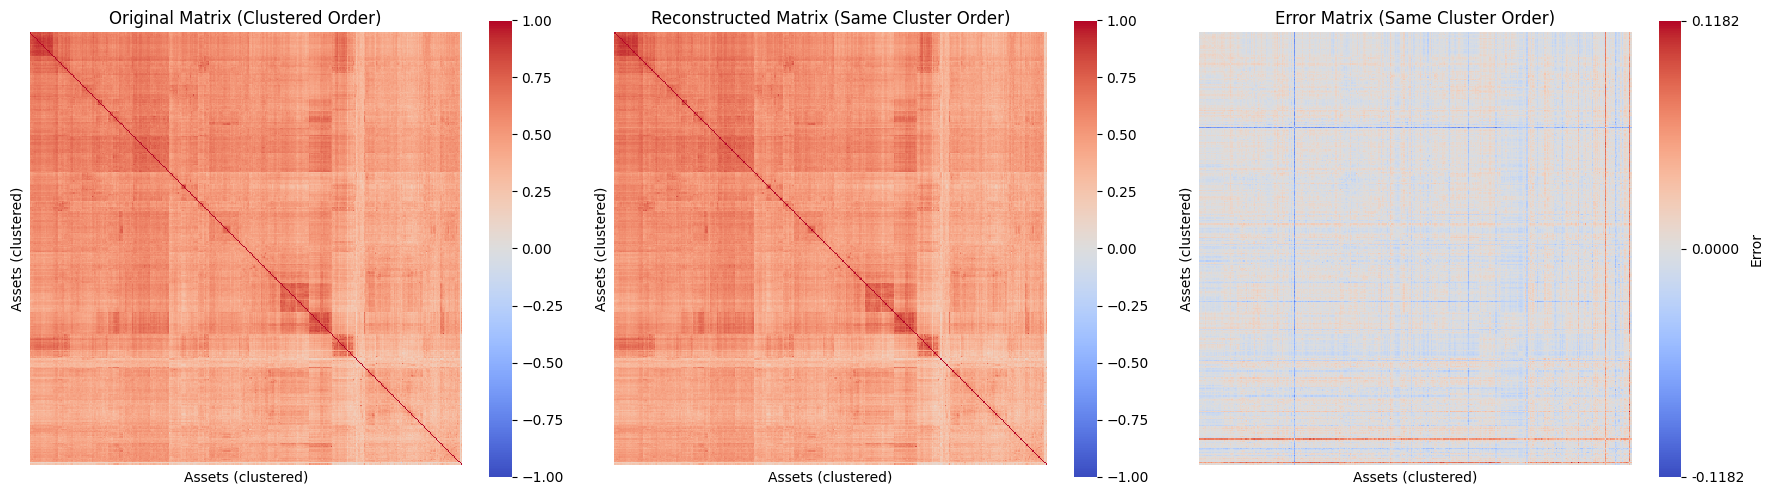

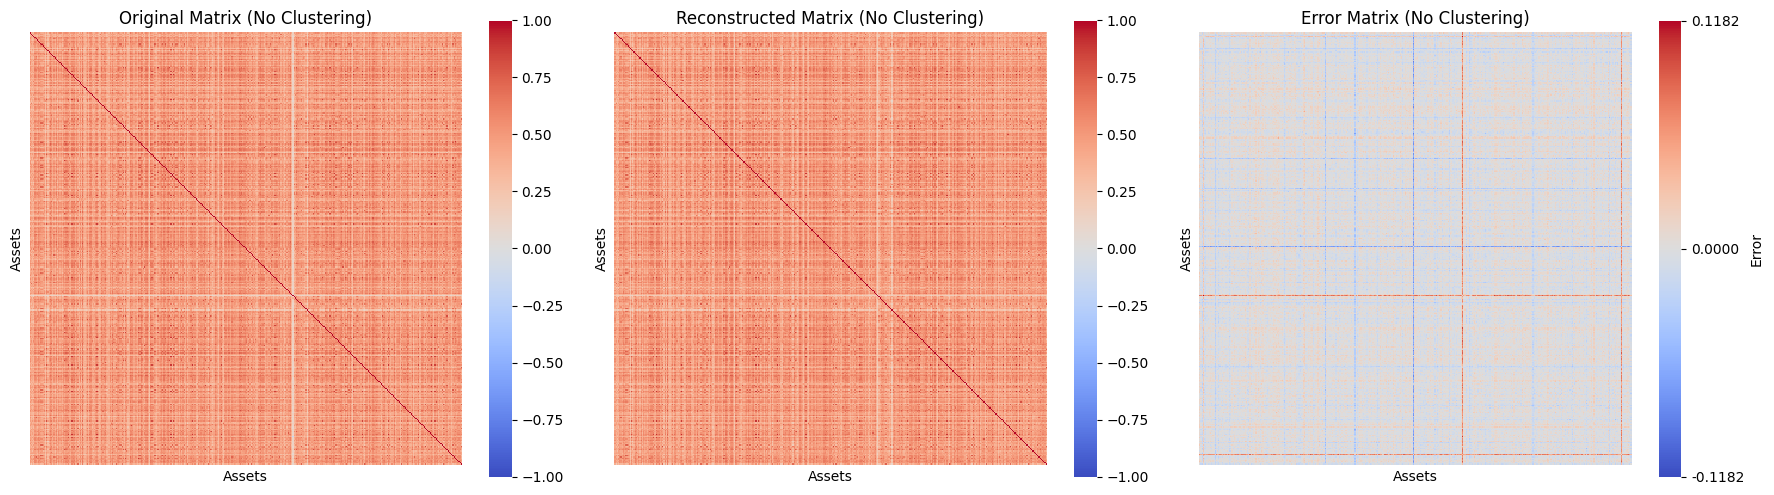

In [9]:
SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 6: Calculate Reconstruction Errors (Test Set)
Measure reconstruction quality on the test split using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [10]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats


orig_corr = test_np
errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Reconstruction error statistics (test set):')
display(errors_stats)

Reconstruction error statistics (test set):


,mean,std,min,median,max
MSE,0.000305,0.000126,0.000121,0.000263,0.000560
MAE,0.012790,0.002936,0.007838,0.012512,0.018273
Frobenius,6.194667,1.296232,3.981852,5.867035,8.568990


## Step 7: Error Analysis Across Components
Sweep over different numbers of K components, fitting PCA on the train split and evaluating reconstruction errors on the test set.

In [11]:
# Error evaluation varying number of components (PCA fit on train, reconstruction on test)
import json

candidate_components = [1, 3, 12, 15, 20, 30, 40, 50, 70, 100, 150, 200, 289]
max_components = min(n_train, n_assets * n_assets)
candidate_components = [c for c in candidate_components if c <= max_components]
print(f'Evaluating reconstruction errors for components: {candidate_components}')



base_payload = torch.load(TEST_FILE, map_location='cpu')
if isinstance(base_payload, dict):
    base_payload_template = base_payload
else:
    base_payload_template = {'corr_tensor': base_payload}

tickers = None
if isinstance(base_payload, dict):
    if 'tickers' in base_payload:
        tickers = base_payload.get('tickers')
    else:
        meta = base_payload.get('meta') or base_payload.get('metadata')
        if isinstance(meta, dict) and 'tickers' in meta:
            tickers = meta.get('tickers')

rows = []
sweep_payload = []
stat_cols = ["mean", "std", "min", "median", "max"]

for n_comp in candidate_components:
    # Prepare output directory and base payload (same save format as notebook 09)
    recon_dir = Path(f'../models/PCA/PCA_{n_comp}dim/analysis_outputs')
    recon_dir.mkdir(parents=True, exist_ok=True)
    recon_out = rank_k_reconstruct_flattened(train_np, test_np, n_comp)
    recon = recon_out['recon_corr']
    _, stats = reconstruction_errors(test_np, recon)
    explained_ratio = recon_out['explained_variance']
    cum_explained_ratio = float(explained_ratio.sum())

    # Save reconstructed test matrices for this K (same payload structure as notebook 09)
    extended_payload = dict(base_payload_template)
    extended_payload['corr_tensor_reconstructed'] = torch.from_numpy(recon).float()
    if tickers is not None:
        extended_payload['tickers'] = tickers
    output_path = recon_dir / f'all_reconstructed_PCA_{n_comp}dim.pt'
    torch.save(extended_payload, output_path)
    print(f'Saved reconstructed matrices for K={n_comp}: {output_path.resolve()}')

    err_stats = {}
    for metric_name in ["MSE", "MAE", "Frobenius"]:
        if metric_name in stats.index:
            metric_stats = stats.loc[metric_name, stat_cols]
            err_stats[metric_name] = {k: float(metric_stats[k]) for k in stat_cols}

    rows.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'MSE_mean': float(err_stats["MSE"]["mean"]),
        'MAE_mean': float(err_stats["MAE"]["mean"]),
        'Frobenius_mean': float(err_stats["Frobenius"]["mean"])
    })

    sweep_payload.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'reconstruction_errors': err_stats,
    })

sweep_df = pd.DataFrame(rows)
display(sweep_df)

sweep_path = Path(f'../results/{DATASET_NAME}/reconstruction_analysis/PCA/reconstruction_errors.json')
sweep_path.parent.mkdir(parents=True, exist_ok=True)
with open(sweep_path, 'w') as f:
    json.dump(sweep_payload, f, indent=2)
print(f'Saved sweep_payload to: {sweep_path.resolve()}')

Evaluating reconstruction errors for components: [1, 3, 12, 15, 20, 30, 40, 50, 70, 100, 150, 200, 289]
Saved reconstructed matrices for K=1: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\PCA\PCA_1dim\analysis_outputs\all_reconstructed_PCA_1dim.pt
Saved reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\PCA\PCA_3dim\analysis_outputs\all_reconstructed_PCA_3dim.pt
Saved reconstructed matrices for K=12: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\PCA\PCA_12dim\analysis_outputs\all_reconstructed_PCA_12dim.pt
Saved reconstructed matrices for K=15: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\PCA\PCA_15dim\analysis_outputs\all_reconstructed_PCA_15dim.pt
Saved reconstructed matrices for K=20: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\PCA\PCA_20dim\analysis_outputs\all_reconstructed_PCA_20dim.pt
Sa

,n_components,mean_explained_variance,MSE_mean,MAE_mean,Frobenius_mean
0,1,0.682023,0.004756,0.053000,24.553282
1,3,0.863957,0.001921,0.031826,14.982809
2,12,0.982418,0.000305,0.012790,6.194669
3,15,0.986362,0.000231,0.011172,5.389200
4,20,0.990651,0.000167,0.009447,4.566982
5,30,0.994756,0.000102,0.007401,3.544964
6,40,0.996455,0.000077,0.006361,3.059719
7,50,0.997378,0.000063,0.005737,2.760846
8,70,0.998425,0.000047,0.004924,2.373799
9,100,0.999147,0.000037,0.004272,2.065193


Saved sweep_payload to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\reconstruction_analysis\PCA\reconstruction_errors.json


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance** from the PCA fit on the train set (top K)
2. **Reconstruction errors** (MSE, MAE, Frobenius) computed on the test set

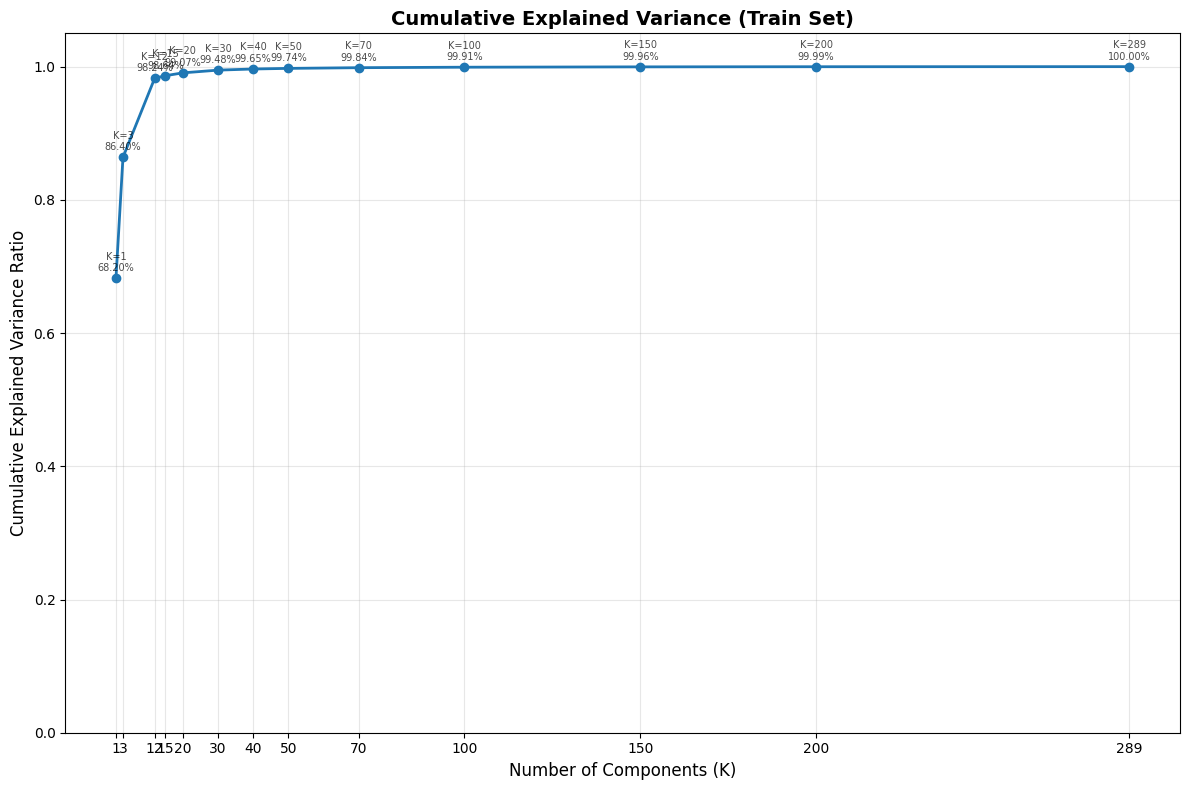

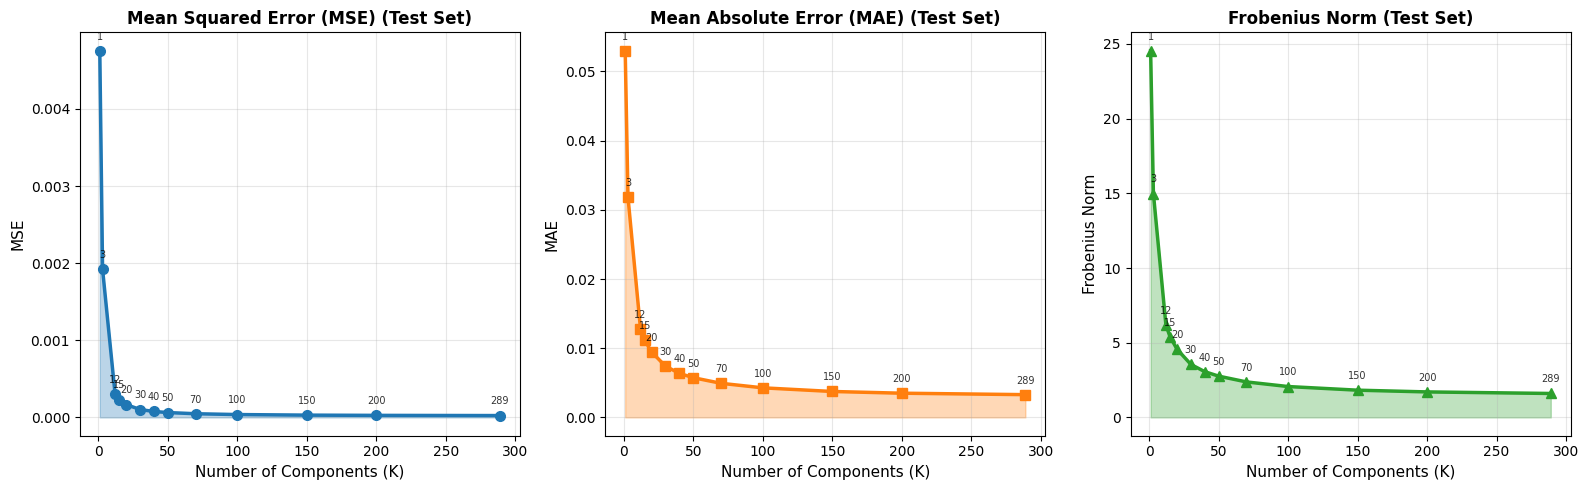

In [12]:
# Plot 1: Cumulative Explained Variance (train fit)
fig1, ax1 = plt.subplots(figsize=(12, 8))

k_values = sweep_df['n_components'].to_numpy()
mean_cum_var = sweep_df['mean_explained_variance'].to_numpy()
ax1.plot(k_values, mean_cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for k, val in zip(k_values, mean_cum_var):
    ax1.annotate(f'K={int(k)}\n{val*100:.2f}%',
                 xy=(k, val),
                 xytext=(0, 5),
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title('Cumulative Explained Variance (Train Set)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Components (K)', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Reconstruction Errors on Test Set with separate subplots for each metric
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE subplot
axes[0].plot(sweep_df['n_components'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MSE_mean'])):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE) (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Components (K)', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE subplot
axes[1].plot(sweep_df['n_components'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MAE_mean'])):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE) (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components (K)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frobenius norm subplot
axes[2].plot(sweep_df['n_components'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['Frobenius_mean'])):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm (Test Set)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Components (K)', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()